# Unconstrained bi-objective optimization - Bi-SEGO


In [1]:
from smt_optim.acquisition_strategies.bisego import BiSEGO
from smt_optim.acquisition_strategies import MFSEGO

import numpy as np

from smt_optim.core import Problem
from smt_optim.surrogate_models.smt import SmtGPX,SmtAutoModel
from smt_optim.core import ObjectiveConfig, DriverConfig
from smt_optim.core import Driver

from smt_optim.benchmarks.registry import list_problems, get_problem

import matplotlib.pyplot as plt

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.indicators.igd_plus import IGDPlus
from pymoo.indicators.hv import HV

from smt_optim.acquisition_strategies.mosego import MOSEGO
from smt_optim.acquisition_functions import init_ehvi_2o

from smt_optim.utils.inject_doe import InjectData
from smt.sampling_methods import LHS
import smt.design_space as ds

from datetime import datetime
import pickle
import glob

### Parameters for optimization

In [2]:
n_accuracy=100 # Precision on composite acquisition function
seed=421 # Seed for generating the initial DoE
budget_factor=20 # Budget: budget_factor * dim
init_factor=2 # Initial DoE size: init_factor * dim + 1
min_factor=2 # Initial calls to determine min(f1): min_factor * dim + 1 (same for min(f2))
max_so_iter_factor=2 # Max calls to a single-objective subproblem: max_so_iter_factor * dim + 1
soformulation_naive="Normalized"
soformulation_composite="Product"
multi_start_factor=10 # Number of multistart calls for acquisition function optimization: multi_start_factor * dim
test_number=0
surrogate=SmtAutoModel


### Importing a test function

Here, we are using the analytical test function ZDT1 in 2 dimensions as an example.

In [3]:
bproblem = get_problem("ZDT1")
bproblem.set_dim(2)

### Initialize the problem:

In [4]:
name=bproblem.name
num_dim=bproblem.num_dim
num_obj=bproblem.num_obj
num_cstr=bproblem.num_cstr
bounds=bproblem.bounds
objective=bproblem.objective

assert(num_obj==2)
assert(num_cstr==0)

f1=objective[0]
f2=objective[1]

max_budget=budget_factor*num_dim
n_init=init_factor*num_dim+1
n_min=min_factor*num_dim+1
n_so=max_so_iter_factor*num_dim+1

obj_config1 = ObjectiveConfig(
    [f1],
    type="minimize",
    surrogate=surrogate,
)

obj_config2 = ObjectiveConfig(
    [f2],
    type="minimize",
    surrogate=surrogate,
)

prob_definition = Problem(
    obj_configs=[obj_config1,obj_config2],
    design_space=bounds,
    costs=[1,1]
)

Initialize the DoE using Latin Hypercube Sampling

In [5]:
float_vars = []
for idx in range(bounds.shape[0]):
    float_vars.append(
        ds.FloatVariable(bounds[idx, 0], bounds[idx, 1])
    )
design_space = ds.DesignSpace(float_vars)

F=lambda x: (f1(x),f2(x))
sampler = LHS(xlimits=design_space.get_unfolded_num_bounds(),
                            criterion="ese",
                            seed=seed, )
doe = sampler(n_init)
D=[x for x in doe]
Y=[F(x) for x in D]

Initialize the driver and run the optimization

In [6]:
opt_config = DriverConfig(
    max_iter = max_budget - n_init,
    max_budget = max_budget,
    nt_init = n_init+2*n_min,
    verbose = True,
    scaling = True,
    seed=seed,
)

strategy_kwargs = {
    "n_multi_start":multi_start_factor*num_dim,
    "n_accuracy":n_accuracy,
    "so_formulation":soformulation_composite,
    "single_objective_max_calls":n_so,
    "init_calls":n_min,
    "naive":False,
    "verbose":True,
}

xt_init = np.vstack([np.atleast_1d(x) for x in D])
yt_init = np.vstack([np.atleast_1d(y) for y in Y])

driver = Driver(prob_definition, opt_config, strategy=BiSEGO, strategy_kwargs=strategy_kwargs)

InjectData(driver.state, xt_init, yt_init)

state = driver.optimize()

          iter         budget             HV        spacing       fidelity        gp_time       acq_time
             0              0    3.78341e+00    0.00000e+00            nan            nan            nan
Min(f1) phase
             1              1    5.09267e+00    0.00000e+00              1          0.709          0.836
             2              2    5.09267e+00    0.00000e+00              1          0.690          1.352
             3              3    5.09267e+00    0.00000e+00              1          0.564          1.280
             4              4    5.09267e+00    0.00000e+00              1          0.439          1.112


/home/mauganto/Bureau/biEGO/smt-optim/src/smt_optim/core/driver.py:470: UserWarning: Infill point [1.e-10 1.e+00] already in training data. L2 = 0.0
  warnings.warn(
/home/mauganto/Bureau/biEGO/smt-optim/.venv/lib/python3.14/site-packages/smt/surrogate_models/krg_based/krg_based.py:679: UserWarning: Warning: multiple x input features have the same value (at least same row twice).
  warnings.warn(


             5              5    5.09267e+00    0.00000e+00              1          0.474          1.621
Min(f2) phase
             6              6    5.21103e+00    3.05335e-01              1          0.543          2.126


/home/mauganto/Bureau/biEGO/smt-optim/.venv/lib/python3.14/site-packages/smt/surrogate_models/krg_based/krg_based.py:679: UserWarning: Warning: multiple x input features have the same value (at least same row twice).
  warnings.warn(


             7              7    5.21103e+00    3.43916e-01              1          0.418          0.763


...

            33             33    5.33636e+00    2.49250e-01              1          0.543          2.356


/home/mauganto/Bureau/biEGO/smt-optim/.venv/lib/python3.14/site-packages/smt/surrogate_models/krg_based/krg_based.py:679: UserWarning: Warning: multiple x input features have the same value (at least same row twice).
  warnings.warn(


            34             34    5.33636e+00    2.49250e-01              1          0.541          2.367


/home/mauganto/Bureau/biEGO/smt-optim/.venv/lib/python3.14/site-packages/smt/surrogate_models/krg_based/krg_based.py:679: UserWarning: Warning: multiple x input features have the same value (at least same row twice).
  warnings.warn(


            35             35    5.33636e+00    2.49250e-01              1          0.528          2.391


In [7]:
def get_DoE(state):
    # Gets the DoE in the format (D,Y) where D is the list of evaluation points and Y is the list of objective function values
    Y=state.dataset.export_as_dict()["obj"]
    D=state.dataset.export_as_dict()["x"]
    return (D,Y)

def dominates(p,q):
    # Returns True if point p strictly dominates point q, else returns False
    return (p[0]<q[0] and p[1]<=q[1]) or (p[0]<=q[0] and p[1]<q[1])

def get_Pareto_front(D,Y):
    # Given a DoE (D,Y), returns the list of indices of non-dominated points, sorted by ascending value of f1
    t=len(D)
    front=[]
    for i in range(t):
        if all([not dominates(q,Y[i]) for q in Y]):
            front.append((Y[i][0],i))
    front.sort()
    return [p[1] for p in front]


Obtain the true Pareto front using pymoo with high budget

In [8]:
class PymooProblem(ElementwiseProblem):
    # Formulates a given benchmark problem as a problem solvable by pymoo

    def __init__(self,bprob):
        self.prob=bprob
        super().__init__(n_var=self.prob.num_dim,
                         n_obj=self.prob.num_obj,
                         xl=np.array([coord_bounds[0] for coord_bounds in self.prob.bounds]),
                         xu=np.array([coord_bounds[1] for coord_bounds in self.prob.bounds]))

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = self.prob.objective[0](x)
        f2 = self.prob.objective[1](x)

        out["F"] = [f1, f2]

def run_benchmark_pymoo(bproblem):
    # Runs pymoo with high budget on a given benchmark problem. Returns a list of the Pareto optimal points and a list of the corresponding points in the objective space

    pymoo_problem=PymooProblem(bproblem)
    algorithm = NSGA2(
        pop_size=1000,
        n_offsprings=250,
        sampling=FloatRandomSampling(),
        crossover=SBX(prob=0.9, eta=15),
        mutation=PM(eta=20),
        eliminate_duplicates=True
    )
    termination = get_termination("n_gen", 1000)
    res = minimize(pymoo_problem,
                algorithm,
                termination,
                seed=1,
                save_history=True,
                verbose=True)

    X = res.X
    F = res.F
    return (X,F)

X_true,F_true=run_benchmark_pymoo(bproblem)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |     1000 |     17 |             - |             -
     2 |     1250 |     18 |  0.0120425576 |             f
     3 |     1500 |     26 |  0.0147107720 |             f
     4 |     1750 |     26 |  0.0031005586 |         ideal
     5 |     2000 |     32 |  0.0052941786 |         ideal
     6 |     2250 |     35 |  0.1504788162 |         nadir
     7 |     2500 |     44 |  0.8488294957 |         nadir
     8 |     2750 |     45 |  0.6028072980 |         nadir
     9 |     3000 |     50 |  1.3195495157 |         nadir
    10 |     3250 |     64 |  0.0062469853 |             f
    11 |     3500 |     79 |  0.7033701841 |         nadir
    12 |     3750 |     85 |  4.2727835614 |         nadir
    13 |     4000 |     98 |  0.6164142689 |         nadir
    14 |     4250 |    106 |  0.0028406672 |         nadir
    15 |     4500 |    121 |  0.0009706262 |             f
    16 |     4750 |    134 |  0.0017912732 |            

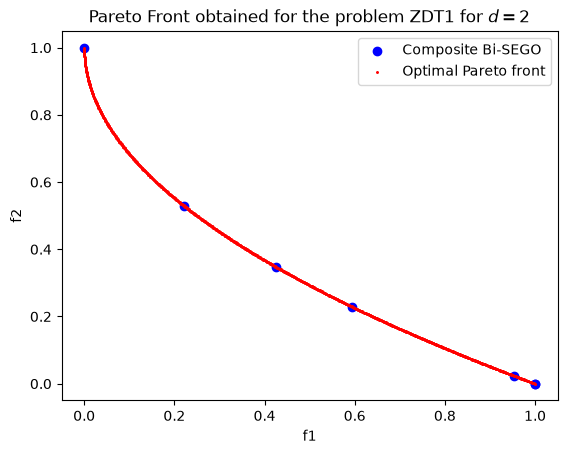

In [9]:
fig,ax=plt.subplots(1,1)

D,Y=get_DoE(state)


pareto_points = [(D[i],Y[i]) for i in get_Pareto_front(D,Y)]
ax.scatter([p[1][0] for p in pareto_points],[p[1][1] for p in pareto_points],color="blue",label="Composite Bi-SEGO")

pareto_points_pymoo = [(X_true[i],F_true[i]) for i in range(len(X_true))]
ax.scatter([p[1][0] for p in pareto_points_pymoo],[p[1][1] for p in pareto_points_pymoo],marker=".",s=5,color="red",label="Optimal Pareto front")

ax.legend(loc="best")
ax.set_xlabel("f1")
ax.set_ylabel("f2")
ax.title.set_text("Pareto Front obtained for the problem ZDT1 for $d = 2$")
ax.legend(loc="best")
ax.set_xlabel("f1")
ax.set_ylabel("f2")

plt.show()

### Comparison of composite and naive versions with Pymoo with same budget

We want to compare both versions of Bi-SEGO with pymoo on a low budget on the ZDT analytical test cases. We want to use the same initial DoE for all 3 algorithms and do the pre-processing of min(f1) and min(f2) beforehand.

Initialize the list of problems and parameters:

In [10]:
L_problems=list_problems(num_obj=[2,2],tags=["zdt"])

surrogate=SmtGPX # Choice of surrogate
n_accuracy=100 # Precision on composite acquisition function
seed=420 # Seed for generating the initial DoE
budget_factor=20 # Budget: budget_factor * dim
init_factor=2 # Initial DoE size: init_factor * dim + 1
min_factor=2 # Initial calls to determine min(f1): min_factor * dim + 1 (same for min(f2))
max_so_iter_factor=2 # Max calls to a single-objective subproblem: max_so_iter_factor * dim + 1
soformulation_naive="Normalized"
soformulation_composite="Product"
multi_start_factor=10 # Number of multistart calls for acquisition function optimization: multi_start_factor * dim

parameters={
    "surrogate":surrogate,
    "n_accuracy":n_accuracy,
    "seed":seed,
    "budget_factor":budget_factor,
    "init_factor":init_factor,
    "min_factor":min_factor,
    "max_so_iter_factor":max_so_iter_factor,
    "soformulation_composite":soformulation_composite,
    "soformulation_naive":soformulation_naive,
    "multi_start_factor":multi_start_factor,
}

Function for running composite or naive Bi-SEGO on a Benchmark problem with a specific input DoE:

In [11]:
def run_benchmark_bisego(bproblem,D,Y,naive=False):
    name=bproblem.name
    print(f"Running {"naive" if naive else "composite"} BiSEGO on benchmark problem",name)
    num_dim=bproblem.num_dim
    num_obj=bproblem.num_obj
    num_cstr=bproblem.num_cstr
    bounds=bproblem.bounds
    objective=bproblem.objective

    assert(num_obj==2)
    assert(num_cstr==0)

    f1=objective[0]
    f2=objective[1]

    max_budget=budget_factor*num_dim
    n_init=init_factor*num_dim+1
    n_min=min_factor*num_dim+1
    n_so=max_so_iter_factor*num_dim+1

    obj_config1 = ObjectiveConfig(
        [f1],
        type="minimize",
        surrogate=surrogate,
    )

    obj_config2 = ObjectiveConfig(
        [f2],
        type="minimize",
        surrogate=surrogate,
    )

    prob_definition = Problem(
        obj_configs=[obj_config1,obj_config2],
        design_space=bounds,            # problem bounds
        costs=[1,1]
    )


    opt_config = DriverConfig(
        max_iter = max_budget - n_init-2*n_min,
        max_budget = max_budget,
        nt_init = n_init+2*n_min,
        verbose = True,
        scaling = True,
        seed=seed,
    )

    strategy_kwargs = {
        "n_multi_start":multi_start_factor*num_dim,
        "n_accuracy":n_accuracy,
        "so_formulation":soformulation_composite,
        "single_objective_max_calls":n_so,
        "init_calls":0,
        "naive":naive,
    }

    xt_init = np.vstack([np.atleast_1d(x) for x in D])
    yt_init = np.vstack([np.atleast_1d(y) for y in Y])

    driver = Driver(prob_definition, opt_config, strategy=BiSEGO, strategy_kwargs=strategy_kwargs)

    InjectData(driver.state, xt_init, yt_init)

    state = driver.optimize()
    return state

Function for running MO-SEGO with same budget as comparison:

In [12]:
def run_benchmark_mosego(bproblem,D,Y):
    name=bproblem.name
    print(f"Running MO-SEGO on benchmark problem",name)
    num_dim=bproblem.num_dim
    num_obj=bproblem.num_obj
    num_cstr=bproblem.num_cstr

    assert(num_obj==2)
    assert(num_cstr==0)
    max_budget=budget_factor*num_dim
    n_init=init_factor*num_dim+1
    n_min=min_factor*num_dim+1
    
    # initialize the first objective configuration
    obj1_config = ObjectiveConfig(
        [bproblem.f1],
        type="minimize",
        surrogate=surrogate,
    )

    # initialize the second objective configuration
    obj2_config = ObjectiveConfig(
        [bproblem.f2],
        type="minimize",
        surrogate=surrogate,
    )

    # initialize the problem configuration
    prob_definition = Problem(
        obj_configs=[obj1_config, obj2_config],
        design_space=bproblem.bounds,
    )

    # initialize the driver
    opt_config = DriverConfig(
        max_iter = max_budget - n_init-2*n_min,
        max_budget = max_budget,
        nt_init = n_init+2*n_min,
        verbose = True,
        scaling = True,
        seed=0,
    )

    xt_init = np.vstack([np.atleast_1d(x) for x in D])
    yt_init = np.vstack([np.atleast_1d(y) for y in Y])

    driver = Driver(prob_definition, opt_config, MOSEGO, strategy_kwargs={"acq_init": init_ehvi_2o,})

    InjectData(driver.state, xt_init, yt_init)

    # starts the optimization process
    state = driver.optimize()
    return state

Function for running pymoo on a benchmark problem with a low budget and a specific input DoE:

In [13]:
def run_benchmark_pymoo_with_budget(bproblem,D,Y):
    num_dim=bproblem.num_dim
    n_init=init_factor*num_dim+1
    n_i=min_factor*num_dim+1
    budget=budget_factor*num_dim-n_init-2*n_i
    pymoo_problem=PymooProblem(bproblem)

    X = np.array([x.tolist() for x in D])

    all_evaluated_X=[]
    all_evaluated_F=[]


    algorithm = NSGA2(
        pop_size=budget_factor,
        n_offsprings=1,
        sampling=X,
        crossover=SBX(prob=0.9, eta=15),
        mutation=PM(eta=20),
        eliminate_duplicates=True,
    )


    termination = get_termination("n_gen", 2*budget)
    res = minimize(pymoo_problem,
                algorithm,
                termination,
                seed=1,
                save_history=True,
                verbose=True)
    
    for algorithm_state in res.history:
        offspring = algorithm_state.off
        if offspring is not None and len(offspring) > 0:
            all_evaluated_X.append(offspring.get("X"))
            all_evaluated_F.append(offspring.get("F"))

    historical_X = np.vstack(all_evaluated_X)
    historical_F = np.vstack(all_evaluated_F)

    return (historical_X, historical_F)

Function to run a simple EGO subsolver on a problem with a specific input DoE, for solving min(f1) and min(f2):

In [14]:
def SimpleEGO(f,bounds,D,Y,max_iter,strategy=MFSEGO,surrogate=SmtAutoModel,strat_kwargs=None):
    #Runs a default implementation of EGO on a single-objective problem
    obj_config = ObjectiveConfig(
        [f],
        type="minimize",
        surrogate=surrogate,
    )

    prob_definition = Problem(
        obj_configs=[obj_config],
        design_space=bounds,            # problem bounds
    )

    xt_init = np.vstack([np.atleast_1d(x) for x in D])
    yt_init = np.vstack([np.atleast_1d(y) for y in Y])

    opt_config = DriverConfig(
        max_iter = max_iter,
        nt_init = 0,
        verbose = True,
        scaling = True,
        seed=42,
    )

    driver = Driver(prob_definition, opt_config, strategy=strategy,strategy_kwargs=strat_kwargs)
    
    InjectData(driver.state, xt_init, yt_init)

    state = driver.optimize()
    return state

Function to initialize and run all Benchmarks:

In [15]:
def run_all_benchmarks(bproblem):
    #Initialization
    name=bproblem.name
    num_dim=bproblem.num_dim
    print("Running all benchmarks on problem",name,"with dimension",num_dim)
    bounds=bproblem.bounds
    objective=bproblem.objective

    f1=objective[0]
    f2=objective[1]

    n_init=init_factor*num_dim+1

    float_vars = []
    for idx in range(bounds.shape[0]):
        float_vars.append(
            ds.FloatVariable(bounds[idx, 0], bounds[idx, 1])
        )
    design_space = ds.DesignSpace(float_vars)

    F=lambda x: (f1(x),f2(x))
    #init DoE using LHS with given seed
    sampler = LHS(xlimits=design_space.get_unfolded_num_bounds(),
                                criterion="ese",
                                seed=seed, )
    doe = sampler(n_init)
    D=[x for x in doe]
    Y=[F(x) for x in D]
    Ni0=min_factor*num_dim+1
    n_multistart=multi_start_factor*num_dim
    initial_budget=Ni0*2+n_init

    #run min f1 and min f2
    #Initialization

    def F_eval(x):
        #This function is a substitute for F that automatically updates the global DoE when running the EGO subsolver
        y=F(x)
        D.append(x)
        Y.append(y)
        return y

    #Coordinate applications of f
    fa=lambda x:F_eval(x)[0]
    fb=lambda x:F_eval(x)[1]

    #Run EGO on the problems min(f1(x)) and min(f2(x))
    print("Min(f1) phase")
    state=SimpleEGO(fa,bounds,D,[y[0] for y in Y],Ni0,MFSEGO,strat_kwargs={"n_start":n_multistart})
    print("Min(f2) phase")
    state=SimpleEGO(fb,bounds,D,[y[1] for y in Y],Ni0,MFSEGO,strat_kwargs={"n_start":n_multistart})

    #D and Y are initialized

    #bisego benchmark
    state_bisego_composite = run_benchmark_bisego(bproblem,D[:initial_budget],Y[:initial_budget],naive=False)

    #naive benchmark
    state_bisego_naive = run_benchmark_bisego(bproblem,D[:initial_budget],Y[:initial_budget],naive=True)
    
    #mosego benchmark
    state_mosego = run_benchmark_mosego(bproblem,D[:initial_budget],Y[:initial_budget])

    #pymoo_benchmark
    D_pymoo,Y_pymoo = run_benchmark_pymoo_with_budget(bproblem,D[:initial_budget],Y[:initial_budget])

    #True Front
    X,F = run_benchmark_pymoo(bproblem)

    return state_bisego_composite,state_bisego_naive,state_mosego,X,F,D_pymoo,Y_pymoo

Run Benchmark and save optimization data in output files:

In [16]:
filenames=[]

for bproblem in L_problems[2:]:
    for dim in [10]:
        bproblem.set_dim(dim)
        state_composite,state_naive,state_mosego,X,F,X2,F2=run_all_benchmarks(bproblem)
        D_composite,Y_composite=get_DoE(state_composite)
        D_naive,Y_naive=get_DoE(state_naive)
        D_mosego,Y_mosego=get_DoE(state_mosego)
        data_to_save = {
            "name":bproblem.name,
            "num_dim":bproblem.num_dim,
            "D_composite":D_composite,
            "Y_composite":Y_composite,
            "D_naive":D_naive,
            "Y_naive":Y_naive,
            "D_mosego":D_mosego,
            "Y_mosego":Y_mosego,
            "X":X,
            "F":F,
            "X2":X2,
            "F2":F2,
            "parameters":parameters,
        }

        current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

        filename = f"benchmark_run_{bproblem.name}_{dim}_{current_time}.pkl"
        filenames.append(filename)

        with open(filename, "wb") as file:
            pickle.dump(data_to_save, file)

        print(f"Results successfully saved to {filename}")

Running all benchmarks on problem ZDT3 with dimension 10
Min(f1) phase
          iter         budget           fmin           rscv       fidelity        gp_time       acq_time
             0              0    3.70203e-02      0.000e+00            nan            nan            nan
             1              1    1.00000e-10      0.000e+00              1          1.872          3.144
             2              2    1.00000e-10      0.000e+00              1          1.806          1.755
             3              3    1.00000e-10      0.000e+00              1          1.737          1.507
             4              4    1.00000e-10      0.000e+00              1          1.888          1.082
             5              5    1.00000e-10      0.000e+00              1          2.363          1.116
             6              6    1.00000e-10      0.000e+00              1          2.440          0.999
             7              7    1.00000e-10      0.000e+00              1          2.330

Open all files to get data:

In [17]:
saved_files = glob.glob("benchmark_run_*.pkl")
saved_files.sort()

data = []

for filename in saved_files:
    with open(filename, "rb") as file:
        results = pickle.load(file)
        data.append(results)
        print(f"Successfully loaded: {filename}")


Successfully loaded: benchmark_run_ZDT1_10_2026-07-21_18-40-25.pkl
Successfully loaded: benchmark_run_ZDT1_2_2026-07-21_15-49-58.pkl
Successfully loaded: benchmark_run_ZDT1_5_2026-07-21_16-09-43.pkl
Successfully loaded: benchmark_run_ZDT2_10_2026-07-21_21-23-05.pkl
Successfully loaded: benchmark_run_ZDT2_2_2026-07-21_18-42-40.pkl
Successfully loaded: benchmark_run_ZDT2_5_2026-07-21_19-00-14.pkl
Successfully loaded: benchmark_run_ZDT3_10_2026-07-23_16-22-45.pkl
Successfully loaded: benchmark_run_ZDT3_2_2026-07-21_21-25-31.pkl
Successfully loaded: benchmark_run_ZDT3_5_2026-07-21_21-44-44.pkl


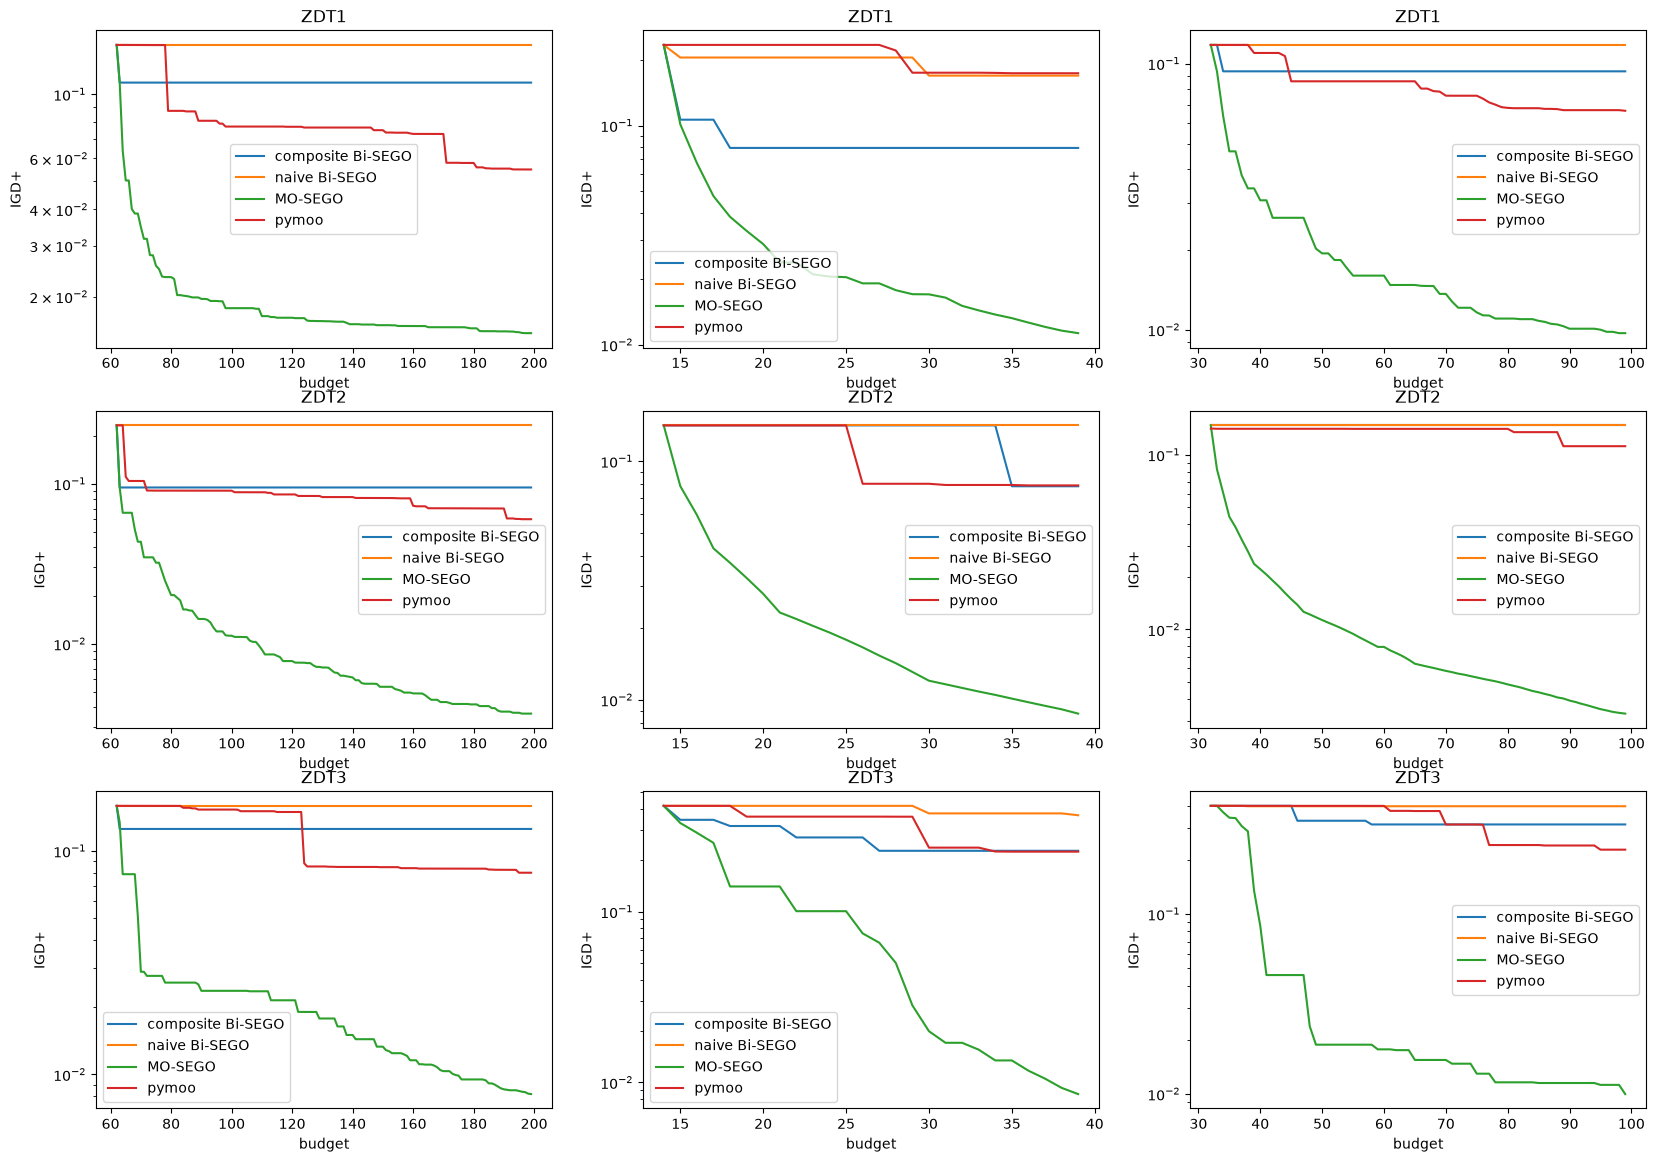

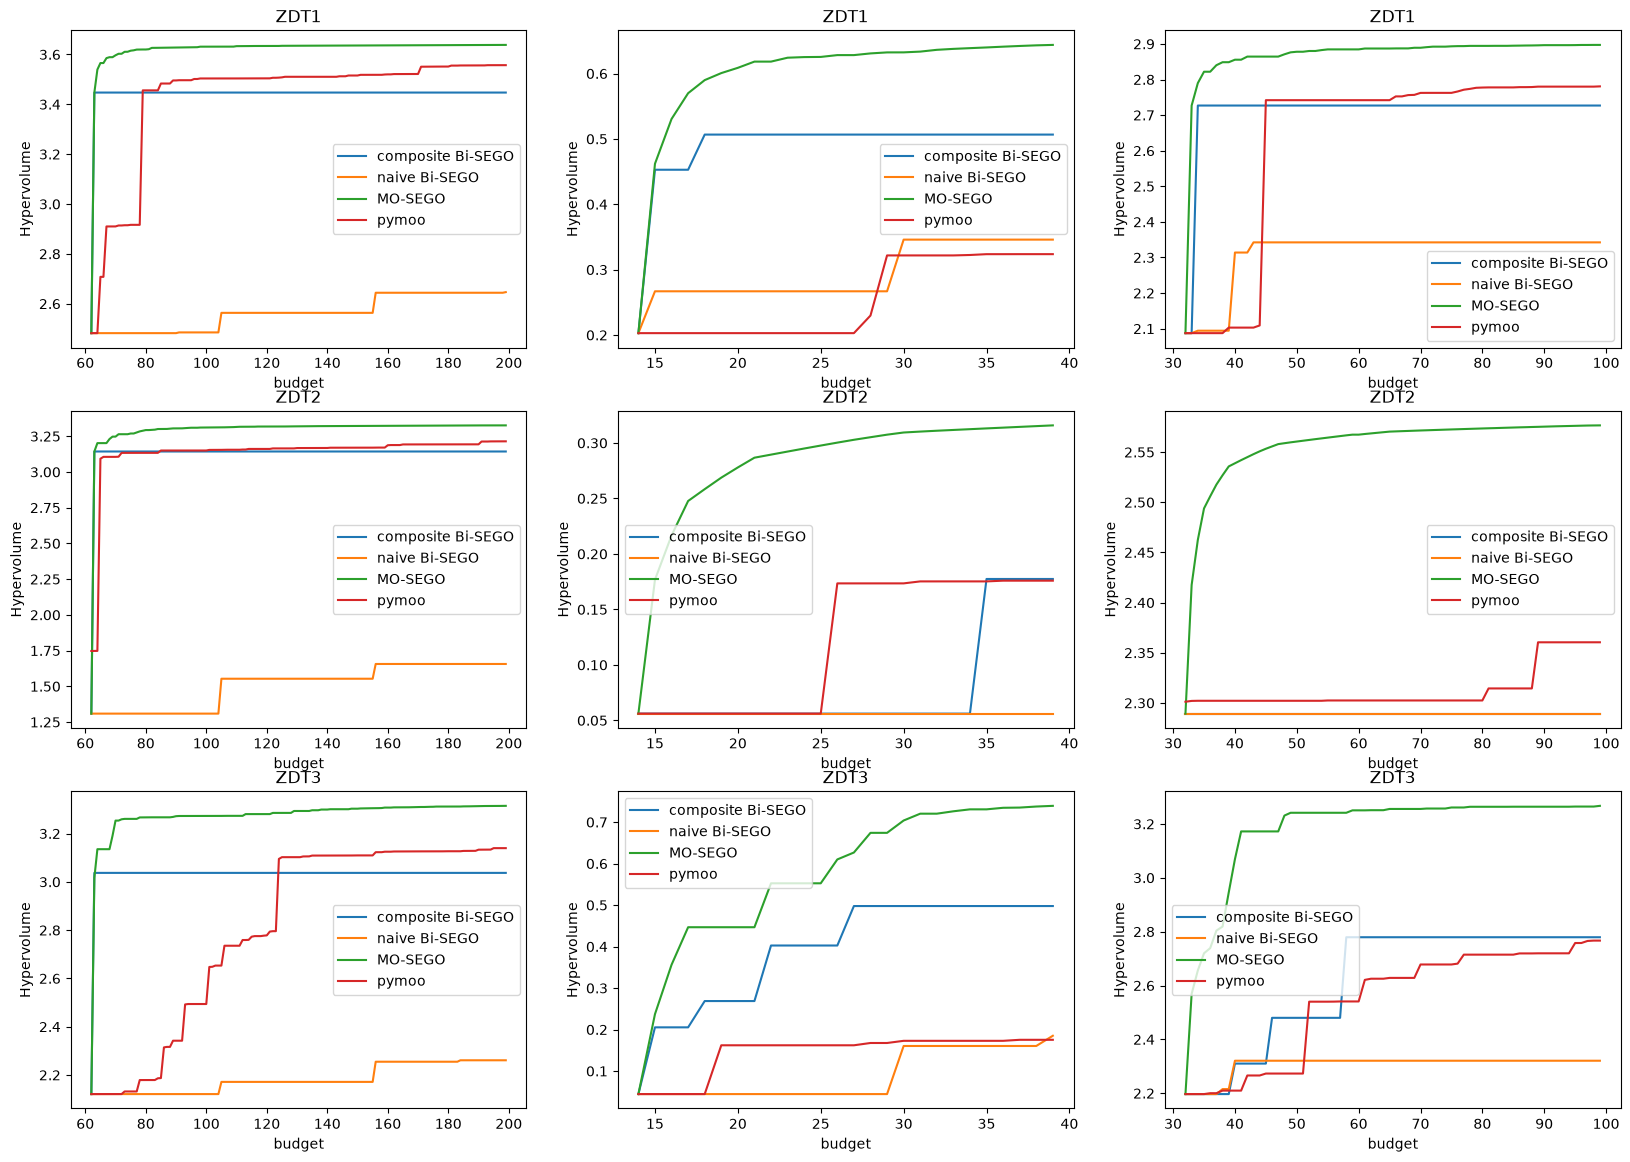

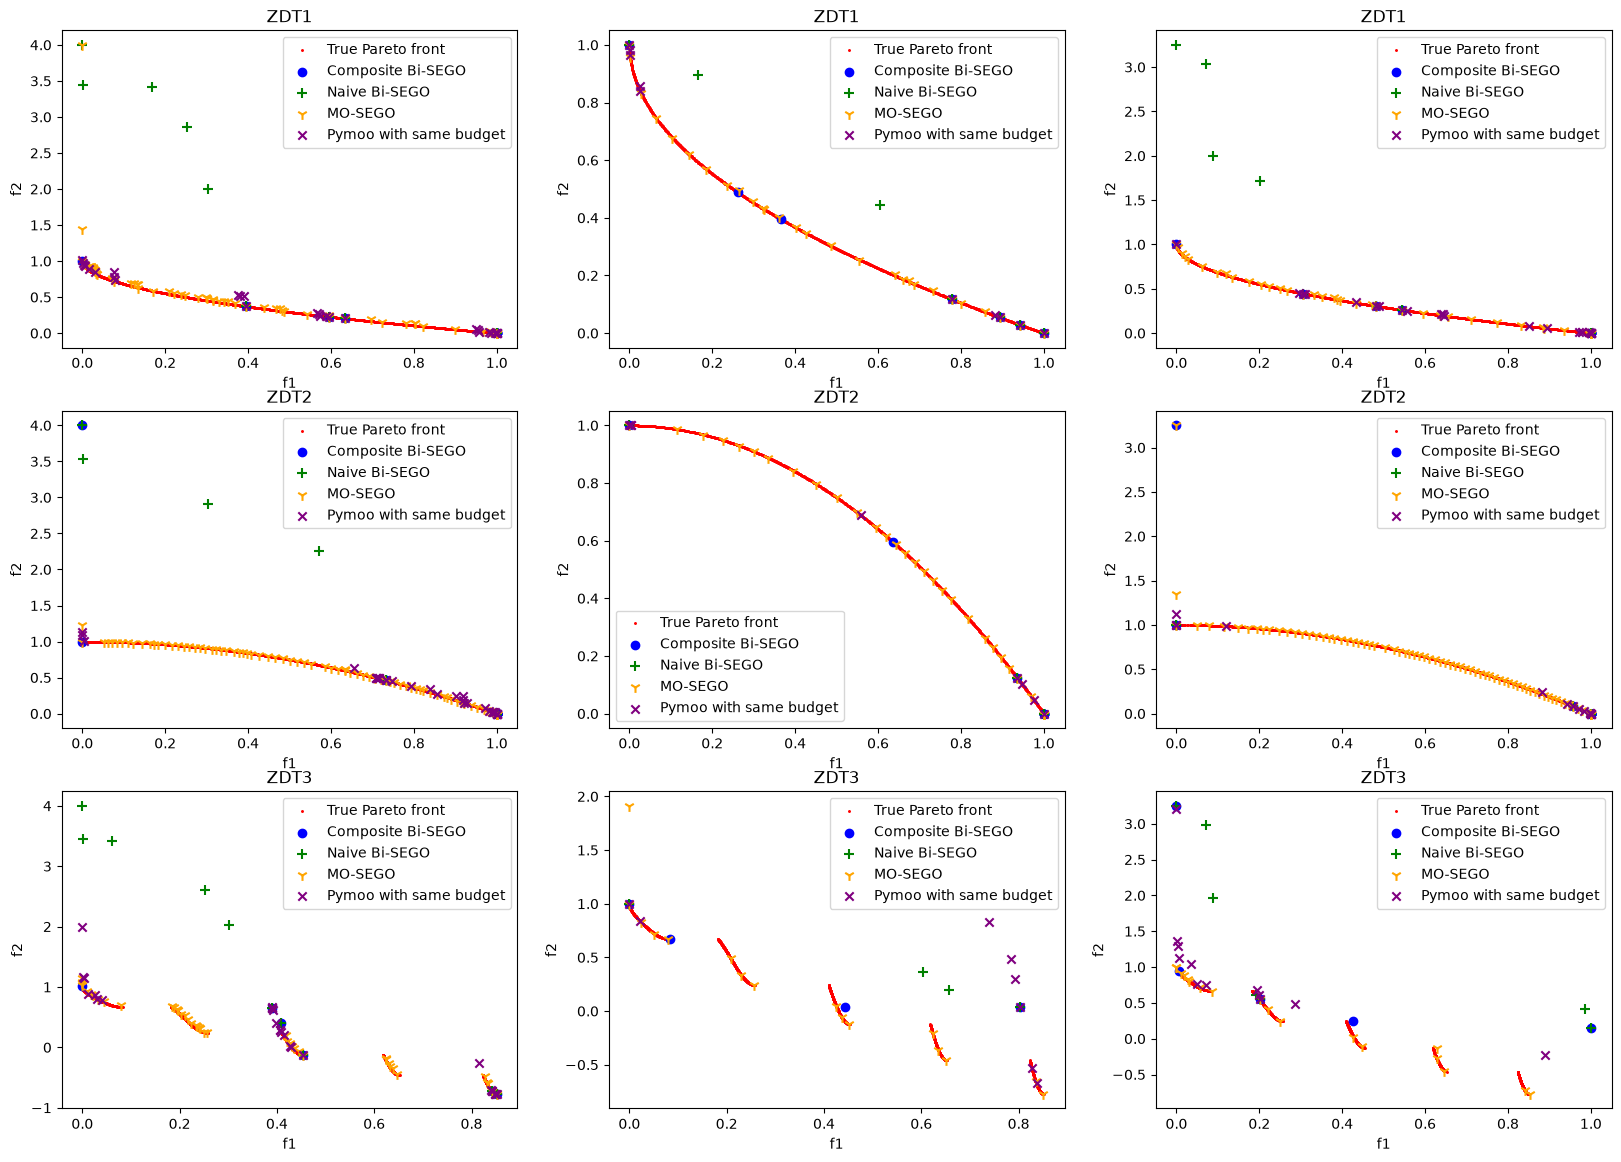

In [18]:
assert(len(data)==9)

fig,axs=plt.subplots(3,3)
fig.set_size_inches(20,14)

for i in range(3):
    for j in range(3):
        index = i*3+j
        num_dim=data[index]["num_dim"]
        ax=axs[i][j]

        initial_budget=(init_factor + 2*min_factor) * num_dim + 3
        total_budget=budget_factor * num_dim

        D_composite,Y_composite=data[index]["D_composite"],data[index]["Y_composite"]
        D_naive,Y_naive=data[index]["D_naive"],data[index]["Y_naive"]
        D_mosego,Y_mosego=data[index]["D_mosego"],data[index]["Y_mosego"]
        X,F=data[index]["X"],data[index]["F"]
        pareto_points_pymoo = [(X[i],F[i]) for i in get_Pareto_front(X,F)]
        X2,F2 = data[index]["X2"],data[index]["F2"]

        T=[i for i in range(initial_budget-1,total_budget)]
        IGD_ac=[]
        IGD_naive=[]
        IGD_mosego=[]
        IGD_pymoo_budget=[]
        for t in T:
            pareto_points_composite = [(D_composite[i],Y_composite[i]) for i in get_Pareto_front(D_composite[:t+1],Y_composite[:t+1])]
            pareto_points_pymoo_budget = [(X2[i],F2[i]) for i in get_Pareto_front(X2[:t+1],F2[:t+1])]
            pareto_points_naive = [(D_naive[i],Y_naive[i]) for i in get_Pareto_front(D_naive[:t+1],Y_naive[:t+1])]
            pareto_points_mosego =[(D_mosego[i],Y_mosego[i]) for i in get_Pareto_front(D_mosego[:t+1],Y_mosego[:t+1])]
            IGD_ac.append(IGDPlus(np.array([pareto_point[1] for pareto_point in pareto_points_pymoo])).do(np.array([pareto_point[1] for pareto_point in pareto_points_composite])))
            IGD_pymoo_budget.append(IGDPlus(np.array([pareto_point[1] for pareto_point in pareto_points_pymoo])).do(np.array([pareto_point[1] for pareto_point in pareto_points_pymoo_budget])))
            IGD_naive.append(IGDPlus(np.array([pareto_point[1] for pareto_point in pareto_points_pymoo])).do(np.array([pareto_point[1] for pareto_point in pareto_points_naive])))
            IGD_mosego.append(IGDPlus(np.array([pareto_point[1] for pareto_point in pareto_points_pymoo])).do(np.array([pareto_point[1] for pareto_point in pareto_points_mosego])))
        ax.semilogy(T,IGD_ac,label="composite Bi-SEGO")
        ax.semilogy(T,IGD_naive,label="naive Bi-SEGO")
        ax.semilogy(T,IGD_mosego,label="MO-SEGO")
        ax.semilogy(T,IGD_pymoo_budget,label="pymoo")
        ax.title.set_text(f"{data[index]["name"]}")
        ax.legend(loc="best")
        ax.set_xlabel("budget")
        ax.set_ylabel("IGD+")

plt.show()

fig,axs=plt.subplots(3,3)
fig.set_size_inches(20,14)

for i in range(3):
    for j in range(3):
        index = i*3+j
        num_dim=data[index]["num_dim"]
        ax=axs[i][j]

        initial_budget=(init_factor + 2*min_factor) * num_dim + 3
        total_budget=budget_factor * num_dim

        D_composite,Y_composite=data[index]["D_composite"],data[index]["Y_composite"]
        D_naive,Y_naive=data[index]["D_naive"],data[index]["Y_naive"]
        D_mosego,Y_mosego=data[index]["D_mosego"],data[index]["Y_mosego"]
        X,F=data[index]["X"],data[index]["F"]
        pareto_points_pymoo = [(X[i],F[i]) for i in get_Pareto_front(X,F)]
        X2,F2 = data[index]["X2"],data[index]["F2"]

        # Find nadir point
        all_pareto_points_composite = [(D_composite[i],Y_composite[i]) for i in get_Pareto_front(D_composite,Y_composite)]
        all_pareto_points_pymoo_budget = [(X2[i],F2[i]) for i in get_Pareto_front(X2[:len(D_composite)],F2[:len(D_composite)])]
        all_pareto_points_naive = [(D_naive[i],Y_naive[i]) for i in get_Pareto_front(D_naive[:len(D_composite)+1],Y_naive[:len(D_composite)+1])]
        ref_point=np.array([max([y[1][0] for y in all_pareto_points_composite]+[y[1][0] for y in all_pareto_points_naive]+[y[1][0] for y in all_pareto_points_pymoo_budget]),max([y[1][1] for y in all_pareto_points_composite]+[y[1][1] for y in all_pareto_points_naive]+[y[1][1] for y in all_pareto_points_pymoo_budget])])

        T=[i for i in range(initial_budget-1,total_budget)]
        HV_ac=[]
        HV_naive=[]
        HV_mosego=[]
        HV_pymoo_budget=[]
        for t in T:
            pareto_points_composite = [(D_composite[i],Y_composite[i]) for i in get_Pareto_front(D_composite[:t+1],Y_composite[:t+1])]
            pareto_points_pymoo_budget = [(X2[i],F2[i]) for i in get_Pareto_front(X2[:t+1],F2[:t+1])]
            pareto_points_naive = [(D_naive[i],Y_naive[i]) for i in get_Pareto_front(D_naive[:t+1],Y_naive[:t+1])]
            pareto_points_mosego =[(D_mosego[i],Y_mosego[i]) for i in get_Pareto_front(D_mosego[:t+1],Y_mosego[:t+1])]
            HV_ac.append(HV(ref_point=ref_point).do(np.array([pareto_point[1] for pareto_point in pareto_points_composite])))
            HV_pymoo_budget.append(HV(ref_point=ref_point).do(np.array([pareto_point[1] for pareto_point in pareto_points_pymoo_budget])))
            HV_naive.append(HV(ref_point=ref_point).do(np.array([pareto_point[1] for pareto_point in pareto_points_naive])))
            HV_mosego.append(HV(ref_point=ref_point).do(np.array([pareto_point[1] for pareto_point in pareto_points_mosego])))

        ax.plot(T,HV_ac,label="composite Bi-SEGO")
        ax.plot(T,HV_naive,label="naive Bi-SEGO")
        ax.plot(T,HV_mosego,label="MO-SEGO")
        ax.plot(T,HV_pymoo_budget,label="pymoo")
        ax.title.set_text(f"{data[index]["name"]}")
        ax.legend(loc="best")
        ax.set_xlabel("budget")
        ax.set_ylabel("Hypervolume")

plt.show()

fig,axs=plt.subplots(3,3)
fig.set_size_inches(20,14)

for i in range(3):
    for j in range(3):
        index = i*3+j
        num_dim=data[index]["num_dim"]
        ax=axs[i][j]

        D_composite,Y_composite=data[index]["D_composite"],data[index]["Y_composite"]
        D_naive,Y_naive=data[index]["D_naive"],data[index]["Y_naive"]
        D_mosego,Y_mosego=data[index]["D_mosego"],data[index]["Y_mosego"]
        X,F=data[index]["X"],data[index]["F"]
        pareto_points_pymoo = [(X[i],F[i]) for i in get_Pareto_front(X,F)]
        X2,F2 = data[index]["X2"],data[index]["F2"]

        ax.scatter([p[1][0] for p in pareto_points_pymoo],[p[1][1] for p in pareto_points_pymoo],color="red",marker=".",s=5,label="True Pareto front")

        pareto_points_composite = [(D_composite[i],Y_composite[i]) for i in get_Pareto_front(D_composite,Y_composite)]
        ax.scatter([p[1][0] for p in pareto_points_composite],[p[1][1] for p in pareto_points_composite],color="blue",label="Composite Bi-SEGO")

        pareto_points_naive=[(D_naive[i],Y_naive[i]) for i in get_Pareto_front(D_naive,Y_naive)]
        ax.scatter([p[1][0] for p in pareto_points_naive],[p[1][1] for p in pareto_points_naive],color="green",label="Naive Bi-SEGO",marker="+",s=60)
        
        pareto_points_mosego=[(D_mosego[i],Y_mosego[i]) for i in get_Pareto_front(D_mosego,Y_mosego)]
        ax.scatter([p[1][0] for p in pareto_points_mosego],[p[1][1] for p in pareto_points_mosego],color="orange",label="MO-SEGO",marker="1",s=60)

        pareto_points_pymoo_budget = [(X2[i],F2[i]) for i in get_Pareto_front(X2[:len(D_composite)],F2[:len(D_composite)])]
        ax.scatter([p[1][0] for p in pareto_points_pymoo_budget],[p[1][1] for p in pareto_points_pymoo_budget],marker="x",color="purple",label="Pymoo with same budget")

        ax.title.set_text(f"""{data[index]["name"]}""")
        ax.legend(loc="best")
        ax.set_xlabel("f1")
        ax.set_ylabel("f2")

plt.show()
